## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The purpose of this analysis is to see if the pour volume several months later has shifted in a meaningful way that would determine if the CO2 regulator is actually the cause of the volume change.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

The volumn in ounces with targe volume 16oz and lower specification limit 15.8oz and upper specificaiton limit 16.2oz.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

CUSUM and EWMA charts are appropriate for this sceniario because they are good at detecting smaller shifts and take into account sequence of time points to measure if over time (regulator aging) if there is a decrease in pressure in the flow tap measured through the volume of beer being below the lower specification limit. Limitations of these charts are they are harder to implement and interpret because they are accumulated points and it is less ovcious how you wuold set control parameters compared to the 3 simga of Shewharts.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [1]:
## Q4 Code ##
user_name <- "Abarre71"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

setwd(setwd("STAT-7110-Quality-Control//Assignments//HW2"))

In [2]:
setwd("STAT-7110-Quality-Control//Assignments//HW2")
getwd()

[1] "/content/STAT-7110-Quality-Control/Assignments/HW2"

In [4]:
# library
install.packages("tidyverse")
install.packages("readxl")
install.packages("qcc")
library(tidyverse)
library(readxl)
library(qcc)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



In [16]:
phaseI <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW2/BustersSportsBar_PhaseI.xlsx")

phaseI |> glimpse()
phaseI

Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


Shift,Pour1,Pour2,Pour3,Pour4,Pour5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,16.0413,16.1330,16.2208,15.9739,16.0762
2,16.0675,16.0046,16.0829,16.0750,16.0499
3,16.0556,15.9970,16.0578,16.0771,16.0694
4,16.0424,16.1595,16.1260,15.9804,16.0306
5,15.9992,15.9692,16.0182,15.9541,15.9968
6,16.0585,16.1351,15.9698,15.9335,16.0919
7,16.1422,16.1080,16.0274,15.9874,16.0022
8,16.2143,15.9941,16.1393,16.0180,16.1102
9,16.1431,16.0765,15.9504,16.0475,16.1165


In [17]:
phaseI<-phaseI |> select(-"Shift")
phaseI
#beer subgroup means in phaseI
subgroup_means <- rowMeans(phaseI)
#beer subgroup ranges in phaseI
subgroup_ranges<- apply(phaseI,1,function(x)max(x)-min(x))
#process mean estimated
mu_hat<-mean(subgroup_means)

sigma_hat <- sd.xbar(phaseI,std.dev="UWAVE-SD")

data.frame(shifts = 1:25,
           Mean = subgroup_means,
           Range = subgroup_ranges)
mu_hat
sigma_hat

Pour1,Pour2,Pour3,Pour4,Pour5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
16.0413,16.1330,16.2208,15.9739,16.0762
16.0675,16.0046,16.0829,16.0750,16.0499
16.0556,15.9970,16.0578,16.0771,16.0694
16.0424,16.1595,16.1260,15.9804,16.0306
15.9992,15.9692,16.0182,15.9541,15.9968
16.0585,16.1351,15.9698,15.9335,16.0919
16.1422,16.1080,16.0274,15.9874,16.0022
16.2143,15.9941,16.1393,16.0180,16.1102
16.1431,16.0765,15.9504,16.0475,16.1165


shifts,Mean,Range
<int>,<dbl>,<dbl>
1,16.08904,0.2469
2,16.05598,0.0783
3,16.05138,0.0801
4,16.06778,0.1791
5,15.98750,0.0641
6,16.03776,0.2016
7,16.05344,0.1548
8,16.09518,0.2202
9,16.06680,0.1927


[1] 16.03856

[1] 0.07532586

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

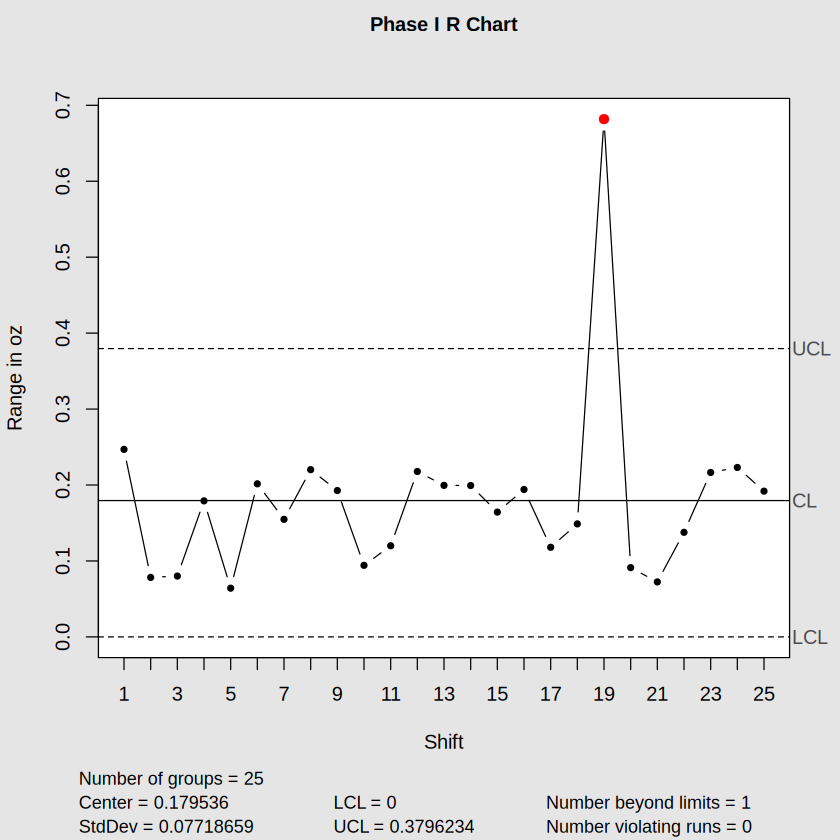

In [19]:
## Q5 Code ##
phaseI_Rchart<-qcc(phaseI, type = "R",title = "Phase I R Chart", xlab = "Shift", ylab = "Range in oz")


You can see that Shift 19 is showing out of control. This could be due to inconsistent pouring techniques during this shift or a change in the CO2 pressure. I will omit Shift 19 and continue the analysis.

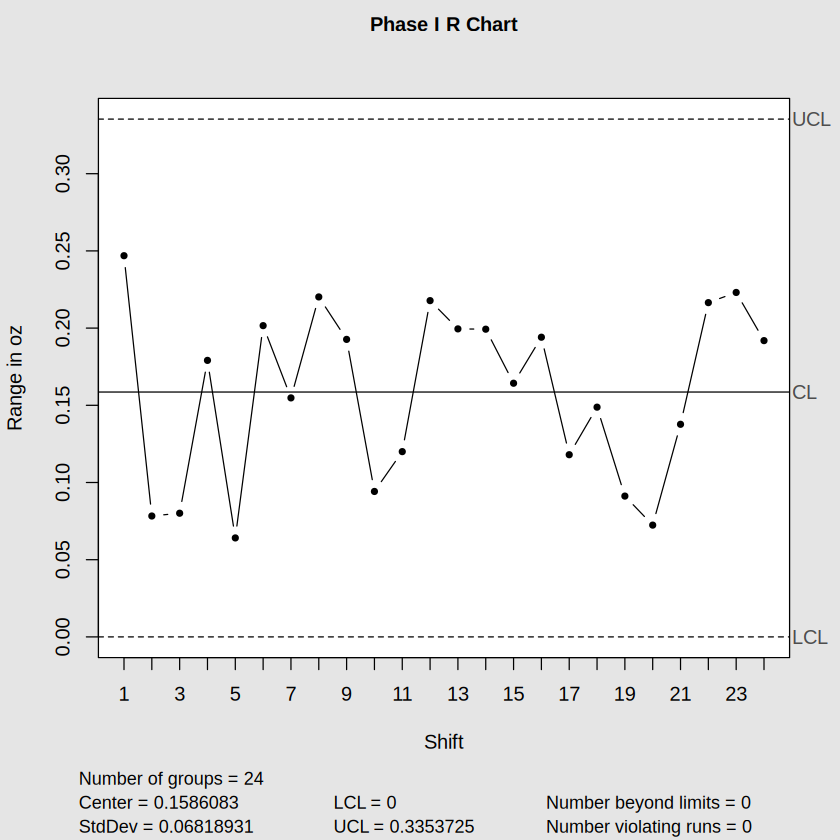

In [26]:
phaseI_19omit<-phaseI[-19,]
phaseI_Rchart_omit19<-qcc(phaseI_19omit,
                   type = "R",
                   title = "Phase I R Chart",
                   xlab = "Shift",
                   ylab = "Range in oz")


Now after omitting Shift 19 it is in statistical control.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

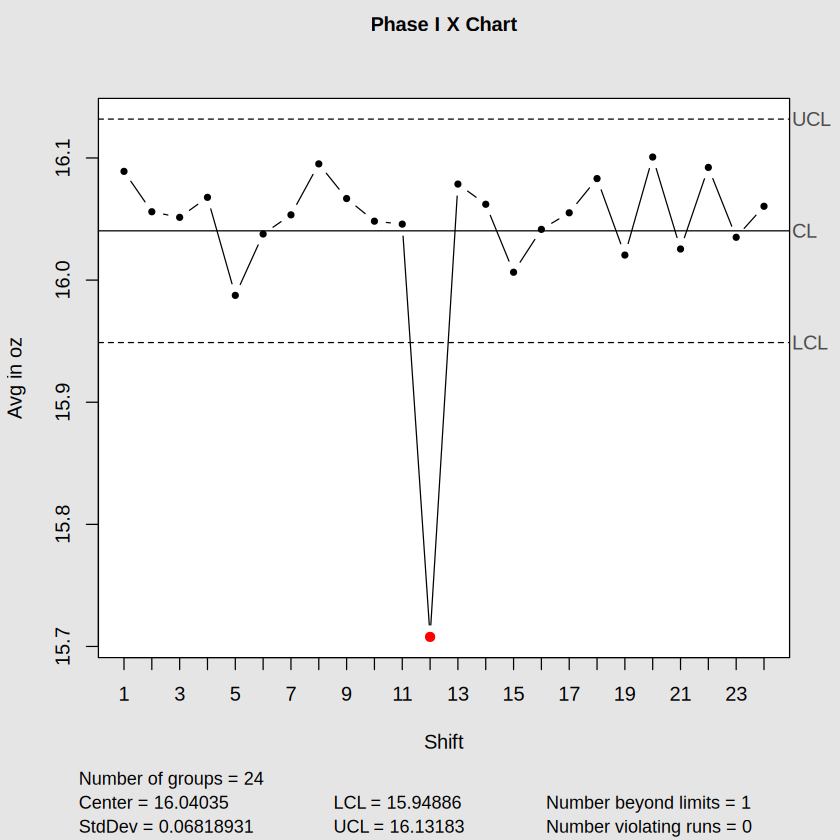

In [27]:
## Q6 Code ##
phaseI_Xchart<-qcc(phaseI_19omit,
                   type = "xbar",
                   title = "Phase I X Chart",
                   xlab = "Shift",
                   ylab = "Avg in oz")

The Xbar chart is showing that Shift 12 is out of the control for average. This could be due to different pouring techniques during the shift or CO2 pressure changes affecting pours. We will omit Shift 12.

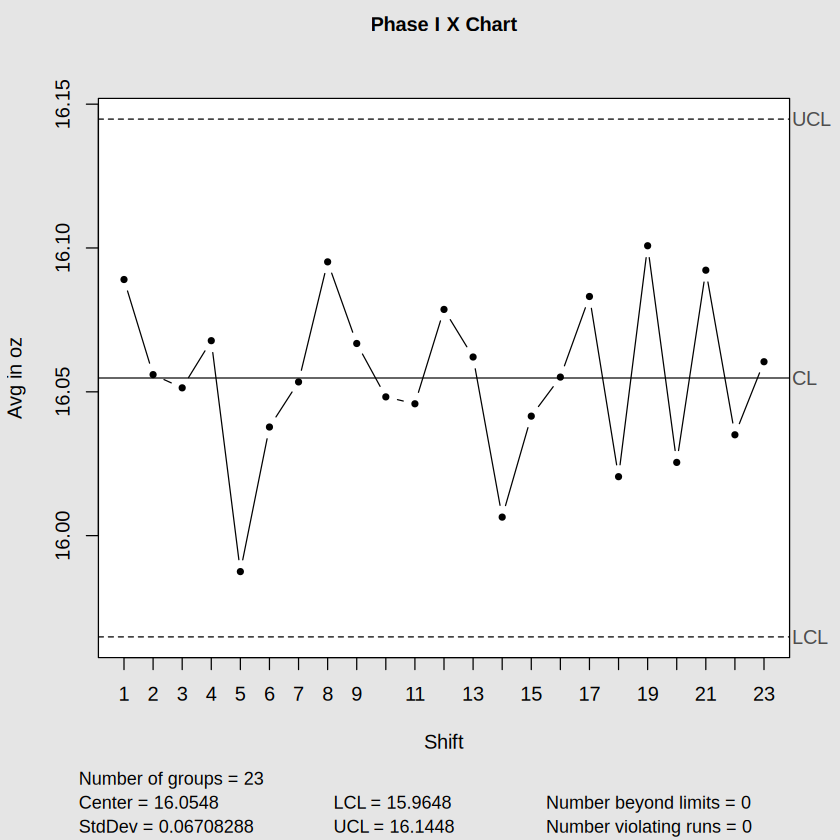

In [41]:
phaseI_19_12omit<-phaseI_19omit[-12,]
phaseI_Xchart_omit12<-qcc(phaseI_19_12omit,
                   type = "xbar",
                   title = "Phase I X Chart",
                   xlab = "Shift",
                   ylab = "Avg in oz")

The Xbar chart now appears to be in statistical control once Shift 12 was removed.

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $PCR$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [34]:
phaseI_Xchart_omit12$center
phaseI_Xchart_omit12$std.dev

[1] 16.0548

[1] 0.06708288

In [39]:
## Q7 Code ##
LSL<-15.8
USL<-16.2
target<-16

FNC<-pnorm(LSL,phaseI_Xchart_omit12$center,phaseI_Xchart_omit12$std.dev) + pnorm(USL,phaseI_Xchart_omit12$center,phaseI_Xchart_omit12$std.dev,lower.tail = FALSE)


Cp<-(USL - LSL)/(6*phaseI_Xchart_omit12$std.dev)


Cpk<-min((USL - phaseI_Xchart_omit12$center)/(3*phaseI_Xchart_omit12$std.dev),(phaseI_Xchart_omit12$center - LSL)/(3*phaseI_Xchart_omit12$std.dev))

Cpm<-(USL - LSL)/(6*sqrt(phaseI_Xchart_omit12$std.dev^2 + (phaseI_Xchart_omit12$center - target)^2))

data.frame(FNC = FNC,
           Cp = Cp,
           Cpk = Cpk,
           Cpm = Cpm)

FNC,Cp,Cpk,Cpm
<dbl>,<dbl>,<dbl>,<dbl>
0.01528784,0.9937955,0.7214826,0.7696239


Based on the FNC it looks like the estimated proportion of pours falling ouside the specification limits is 1.5% which is decent capture. Based on Cp of 0.99 it is barely capable based on the process variability, assuming its centered.  Cpk is 0.72 which is showing that the capability is not good relative to the nearest specification limit while accounting for centering. Cpm of 0.77 is showing that the capability is still not good while penalizing for deviaitons from the target volume. This showing that this process is not capable and not centered.

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

a. We will choose K as 0.5 because the recommendation standard is usually the shift you want to detect over 2, so in our case 1sigma/2. The H is typically 4 or 5 for our case we will select 5 which based on k of sqrt(n)/2 which then using CUSUM ARL talbe is around 465 inbetween the 370-500.

b. We will select a lambda of of 0.2 which will smooth but also give more weight on historical data so we can detect smaller shifts.  I will select L = 3 because it is around ARL of 500.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

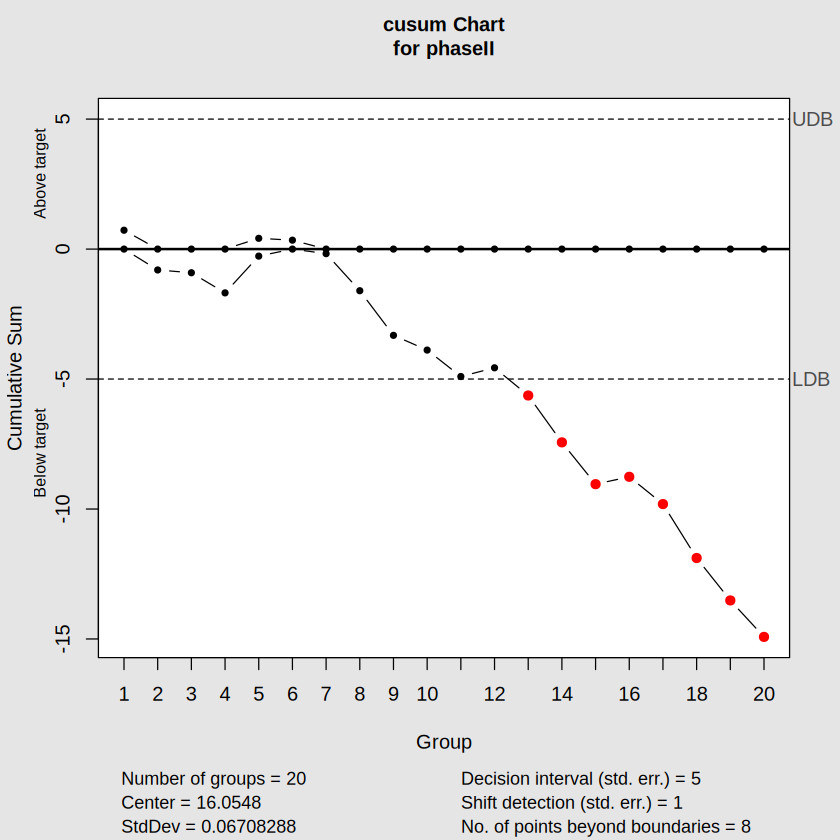

In [55]:
## Q9 Code ##
phaseII <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW2/BustersSportsBar_PhaseII.xlsx")
phaseII <- phaseII |> select(-"Shift")

mu0 <- phaseI_Xchart_omit12
sigma_hat<-phaseI_Xchart_omit12$std.dev

k <- 0.5
h <- 5

phaseII_CUSUM<- cusum(
phaseII,
  center = phaseI_Xchart_omit12$center,
  std.dev = phaseI_Xchart_omit12$std.dev,
  se.shift = k * 2,
  decision.interval = h,
  plot = TRUE
)

Yes, starting at shift 13 to 20 we see the shifts becoming out of control below the lower boundary limit.

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

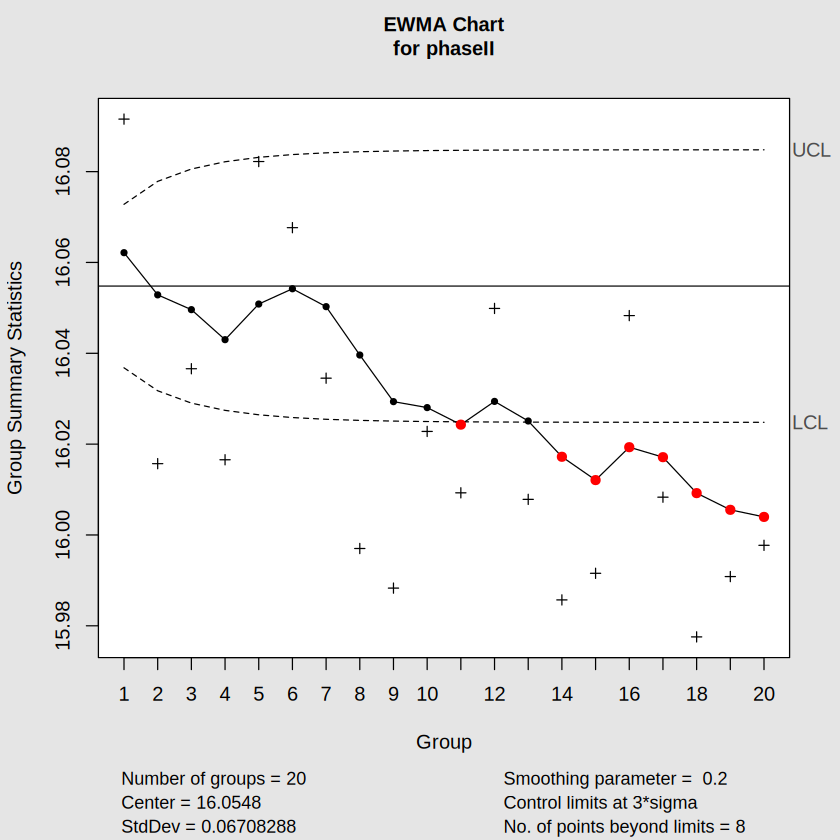

In [58]:
## Q10 Code ##
lambda <- 0.20
L <- 3
phaseII_EWMA<- ewma(
  phaseII,
  center = phaseI_Xchart_omit12$center,
  std.dev = phaseI_Xchart_omit12$std.dev,
  lambda = lambda,
  width = L)


Yes, shift 11 and then shifts 14 through 20 are out of control.

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

The EWMA chart detected the shift earlier than the CUSUM chart by detecting the shift at Shift 11 compared to 13. This makes sense because the EWMA chart with a lambda of 0.2 has greater emphasis on the accumulated historical informaition. These parameters affect the detection sensitivity.

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

Based on the analysis and tests I would conclude that the CO2 regulator does need to be replaced ahead of schedule and that you see a decrease in volume through later shifts. Phase I analysis showed that the cabability was not meeting specifications to the degree we would like based on the limits. Phase II showed that the process does deteriorate in later shifts showing that this could be due to CO2 regulator. Because values were out of control in phase I data I would reiterate that training for proper pouring and consistency should also be considered but due to the CUSUM and EWMA results I think the larger impact to consistent beer volume pours is due to the CO2 regulator.